### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
graph=StateGraph(State)

In [4]:
graph   

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq

llm=ChatGroq(
    model="llama-3.3-70b-versatile"
)



In [14]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [17]:
graph=StateGraph(State)

## Adding node
graph.add_node("llmchatbot",chatbot)
## Adding Edges
graph.add_edge(START,"llmchatbot")
graph.add_edge("llmchatbot",END)

## compile the graph
graph1=graph.compile()

In [20]:
response=graph1.invoke({"messages":"Hey"})

In [21]:
response["messages"]

[HumanMessage(content='Hey', additional_kwargs={}, response_metadata={}, id='ee2edc2d-ba90-4909-ba6b-1d4791218300'),
 AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 36, 'total_tokens': 57, 'completion_time': 0.048299811, 'completion_tokens_details': None, 'prompt_time': 0.008631425, 'prompt_tokens_details': None, 'queue_time': 0.655217047, 'total_time': 0.056931236}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fa29f-c2cf-7ed3-a451-aa7f742d1eff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})]

In [22]:
for event in graph1.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?


### Chatbot with tool

In [25]:
from langchain import tools
from langchain_tavily import TavilySearch
load_dotenv()

tool=TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [41]:

def multiply(a:int,b:int)->int:
    """multiply a and b"""
    return a*b

In [42]:
tools=[tool,multiply]

In [43]:
llm_with_tools=llm.bind_tools(tools)

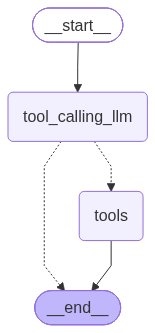

In [44]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)

builder.compile()


In [45]:
graph=builder.compile()


In [48]:
response=graph.invoke({"messages":"What is 5 multiply by 3"})

In [49]:

response['messages'][-1].content

'15'